# Breast Tissue Classification

Comparing Logistic Regression and Random Forest on the UCI Breast Tissue Impedance dataset (106 samples, 6 tissue types, 9 impedance-based features).

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline


## Data Loading and Exploration

In [20]:
df = pd.read_csv('data.csv')
df.head()

#car = carcinoma

,Class,I0,PA500,HFS,DA,Area,A.DA,Max.IP,DR,P
0,car,524.794072,0.187448,0.032114,228.800228,6843.598481,29.910803,60.204880,220.737212,556.828334
1,car,330.000000,0.226893,0.265290,121.154201,3163.239472,26.109202,69.717361,99.084964,400.225776
2,car,551.879287,0.232478,0.063530,264.804935,11888.391827,44.894903,77.793297,253.785300,656.769449
3,car,380.000000,0.240855,0.286234,137.640111,5402.171180,39.248524,88.758446,105.198568,493.701814
4,car,362.831266,0.200713,0.244346,124.912559,3290.462446,26.342127,69.389389,103.866552,424.796503


In [21]:
# What are the data types? Is anything missing?
df.shape
df.info()
df.describe() #summary statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Class   106 non-null    object 
 1   I0      106 non-null    float64
 2   PA500   106 non-null    float64
 3   HFS     106 non-null    float64
 4   DA      106 non-null    float64
 5   Area    106 non-null    float64
 6   A.DA    106 non-null    float64
 7   Max.IP  106 non-null    float64
 8   DR      106 non-null    float64
 9   P       106 non-null    float64
dtypes: float64(9), object(1)
memory usage: 8.4+ KB


,I0,PA500,HFS,DA,Area,A.DA,Max.IP,DR,P
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,784.251618,0.120133,0.114691,190.568642,7335.155162,23.473784,75.381258,166.710575,810.638127
std,753.950075,0.068596,0.101347,190.801448,18580.314213,23.354672,81.345838,181.309580,763.019135
min,103.000000,0.012392,-0.066323,19.647670,70.426239,1.595742,7.968783,-9.257696,124.978561
25%,250.000000,0.067413,0.043982,53.845470,409.647141,8.180321,26.893773,41.781258,270.215238
50%,384.936489,0.105418,0.086568,120.777303,2219.581163,16.133657,44.216040,97.832557,454.108153
75%,1487.989626,0.169602,0.166504,255.334809,7615.204968,30.953294,83.671755,232.990070,1301.559438
max,2800.000000,0.358316,0.467748,1063.441427,174480.476218,164.071543,436.099640,977.552367,2896.582483


## Exploratory Data Analysis

In [22]:
# How balanced are the classes?
df['Class'].value_counts()

,count
Class,
adi,22
car,21
mas,18
gla,16
fad,15
con,14


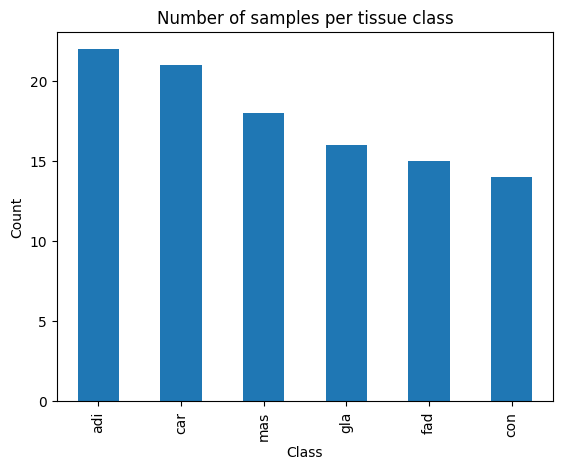

In [23]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Number of samples per tissue class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

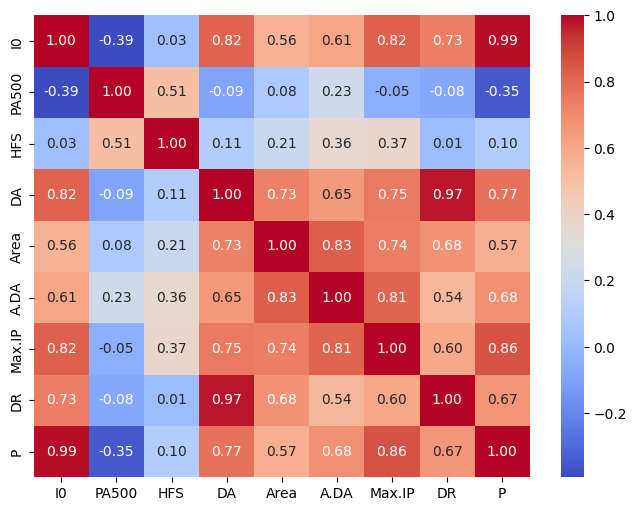

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('Class', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Preprocessing: Train/Test Split and Scaling

In [25]:
X = df.drop('Class', axis=1) #features
y = df['Class'] # output prediction

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify = y, random_state = 42
)

X_train.shape, X_test.shape

((84, 9), (22, 9))

In [26]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled[:3]

array([[-0.64646847,  1.22091427,  3.51821633,  0.01697905, -0.10085651,
         0.20848503, -0.46520454,  0.12241812, -0.4737758 ],
       [-0.11847749, -1.3527218 , -0.29331356, -0.00406597, -0.35791468,
        -0.89386008, -0.62578093,  0.10857138, -0.27647964],
       [-0.56918651,  0.01491089, -0.25142862, -0.616945  , -0.32051734,
        -0.3204104 , -0.37824865, -0.6062662 , -0.55701559]])

## Model Training

In [28]:
#Training
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
# Accuracy
y_pred = log_reg.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.6818181818181818

In [30]:
# Second Model - Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train) #unscaled because trees dont need scaling

y_pred_rf = rf.predict(X_test)

y_pred_rf

array(['car', 'car', 'con', 'con', 'gla', 'fad', 'fad', 'con', 'car',
       'gla', 'adi', 'adi', 'adi', 'adi', 'car', 'mas', 'fad', 'gla',
       'gla', 'car', 'fad', 'con'], dtype=object)

In [31]:
accuracy_score(y_test, y_pred_rf)

0.7272727272727273

## Model Evaluation

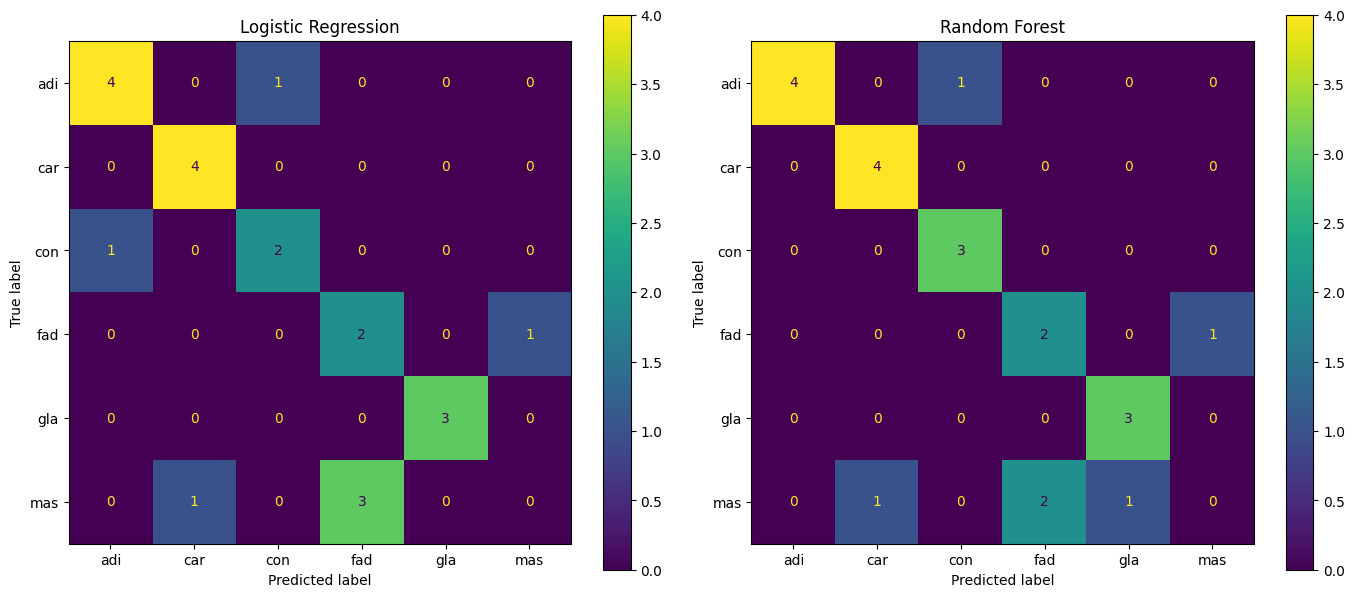

In [37]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

In [40]:
print("Logistic Regression: ")
print(classification_report(y_test, y_pred))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Logistic Regression: 
              precision    recall  f1-score   support

         adi       0.80      0.80      0.80         5
         car       0.80      1.00      0.89         4
         con       0.67      0.67      0.67         3
         fad       0.40      0.67      0.50         3
         gla       1.00      1.00      1.00         3
         mas       0.00      0.00      0.00         4

    accuracy                           0.68        22
   macro avg       0.61      0.69      0.64        22
weighted avg       0.61      0.68      0.64        22

Random Forest
              precision    recall  f1-score   support

         adi       1.00      0.80      0.89         5
         car       0.80      1.00      0.89         4
         con       0.75      1.00      0.86         3
         fad       0.50      0.67      0.57         3
         gla       0.75      1.00      0.86         3
         mas       0.00      0.00      0.00         4

    accuracy                           0.

In [41]:
#Random Forest
rf_scores = cross_val_score(rf, X, y, cv=5)
print("Random Forest: ", rf_scores, "average: ", rf_scores.mean())

#Logistic Regression. scaler + model in one pipeline
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg_scores = cross_val_score(log_reg_pipeline, X, y, cv = 5)
print("Logistic Regression: ", log_reg_scores, "average: ", log_reg_scores.mean())

Random Forest:  [0.59090909 0.76190476 0.71428571 0.71428571 0.61904762] average:  0.6800865800865801
Logistic Regression:  [0.68181818 0.57142857 0.61904762 0.66666667 0.71428571] average:  0.6506493506493507


## Conclusions

Random Forest slightly outperformed Logistic Regression (73% vs 68% test accuracy; confirmed by 5-fold cross-validation at 68% against 65% average accuracy).

Both models however, completely failed to correctly identify the 'mas' (mastopathy) tissue class (0% recall for both), suggesting this class is genuinely hard to differentiate from the others using these 9 impedance features alone, rather than being a weakness specific to one algorithm.

Two feature pairs ('I0'/'P' and 'DA'/'DR') were found to be highly correlated (>0.95), indicating some redundancy in the measurements.

Given the small dataset size (106 rows), these results should be interpreted with some caution, cross validation scores varied notably across folds (e.g. Random Forest ranged from 0.59 to 0.76).